In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import json

def solve_nan(l):
    return [None if np.isnan(x) else x for x in l]

def adapt_df(csv):
    df=pd.read_csv(csv, parse_dates=["timestamp"])
    df["date"]=df["timestamp"].dt.date

    zone1=list(df["Zona1"])
    man_izq=list(df["mano_izq"])
    man_drc=list(df["mano_drc"])
    pie_izq=list(df["pie_izq"])
    pie_drc=list(df["pie_drc"])

    zone1=solve_nan(zone1)
    man_izq=solve_nan(man_izq)
    man_drc=solve_nan(man_drc)
    pie_izq=solve_nan(pie_izq)
    pie_drc=solve_nan(pie_drc)

    zone3=[]
    for a, b, c, d in zip(man_izq, man_drc, pie_izq, pie_drc):
        if(a and b):
            zone3.append(float(np.mean([a, b])))
        elif a:
            zone3.append(a)
        elif b:
            zone3.append(b)
        elif c and d:
            zone3.append(float(np.mean([c, d])))
        elif c:
            zone3.append(c)
        elif d:
            zone3.append(d)
        else:
            zone3.append(None)

    diffs=[]
    for a, b in zip(zone1, zone3):
        if(a and b):
            diffs.append(a-b)
        else:
            diffs.append(None)

    df["diffs"]=pd.Series(diffs)

    df["zone3"]=pd.Series(zone3)

    return df

def plots(df):
    mask_high = df["diffs"] > 3.5
    mask_low = ~mask_high
    points=["Zona1", "codo_izq", "codo_drc", "rodilla_izq", "rodilla_drc", "mano_izq", "mano_drc", "pie_izq", "pie_drc"]

    plt.figure(figsize=(16, 6))

    # Graficar valores normales (azul)
    plt.plot(df["timestamp"][mask_low], df["diffs"][mask_low], marker='o', linestyle='-', color='tab:blue', label='≤ 3.5')

    # Graficar valores altos (rojo)
    plt.plot(df["timestamp"][mask_high], df["diffs"][mask_high], marker='o', linestyle='None', color='red', label='> 3.5')
    plt.grid(True)
    plt.show()
    plt.close()

    for point in points:
        if point == "Zona1":
            plt.figure(figsize=(16, 6))
            plt.plot(df["timestamp"], df[point], marker='o', color='tab:orange', label="zone1")
            
        elif point == "mano_izq":
            plt.plot(df["timestamp"], df["zone3"], marker='o', color='tab:blue', alpha=0.1, label="zone3")

    plt.title(f"Evolución de temperatura: Zone1 vs Zone3")
    plt.xlabel("Tiempo")
    plt.ylabel("Temperatura (°C)")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()
    plt.close()

    mask_high = df["diffs"] > 3.5
    mask_low = ~mask_high

    mask_time = (df["timestamp"] > datetime(2024, 11, 26, 0, 0, 0)) & \
                (df["timestamp"] < datetime(2024, 11, 26, 23, 59, 59))

    mask_low = mask_low & mask_time
    mask_high = mask_high & mask_time

    plt.figure(figsize=(16, 6))

    # Graficar valores normales (azul)
    plt.plot(df["timestamp"][mask_low], df["diffs"][mask_low], marker='o', linestyle='-', color='tab:blue', label='≤ 3.5')

    # Graficar valores altos (rojo)
    plt.plot(df["timestamp"][mask_high], df["diffs"][mask_high], marker='o', linestyle='None', color='red', label='> 3.5')
    plt.grid(True)
    plt.axvline(x=datetime(2024, 11, 26, 18, 30, 0), color='green', linestyle='--', linewidth=2, label='Fever detected by nurse')
    plt.axvline(x=datetime(2024, 11, 26, 18, 31, 0), color='red', linestyle='--', linewidth=2, label='Alarm')
    plt.show()
    plt.close()


    for point in points:
        if point == "Zona1":
            plt.figure(figsize=(16, 6))
            plt.plot(df["timestamp"][mask_time], df[point][mask_time], marker='o', color='tab:orange', label="zone1")
            
        elif point == "mano_izq":
            plt.plot(df["timestamp"][mask_time], df["zone3"][mask_time], marker='o', color='tab:blue', alpha=0.1, label="zone3")

    plt.title(f"Evolución de temperatura: Zone1 vs Zone3")
    plt.xlabel("Tiempo")
    plt.ylabel("Temperatura (°C)")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.axvline(x=datetime(2024, 11, 26, 18, 30, 0), color='green', linestyle='--', linewidth=2, label='Fever detected by nurse')
    plt.axvline(x=datetime(2024, 11, 26, 18, 31, 0), color='red', linestyle='--', linewidth=2, label='Alarm')
    plt.legend()
    plt.show()
    plt.close()

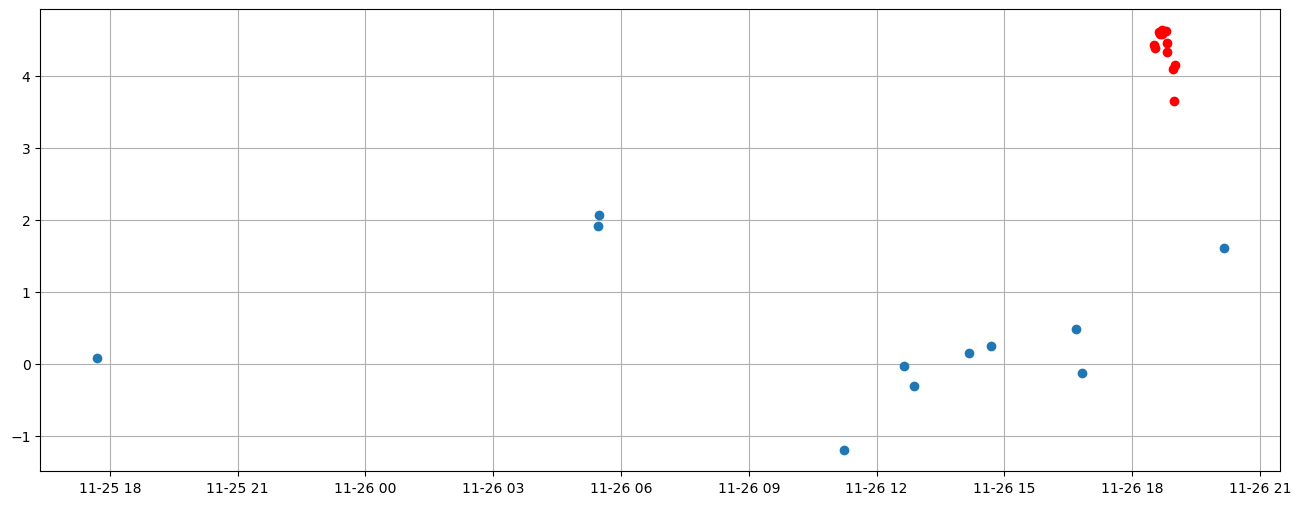

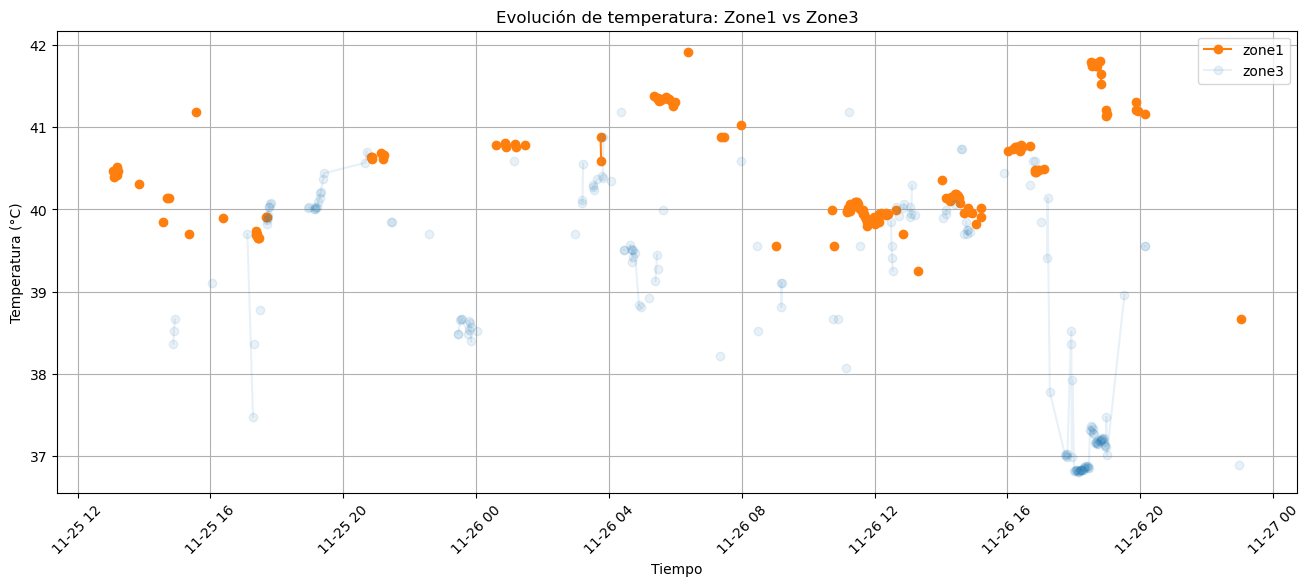

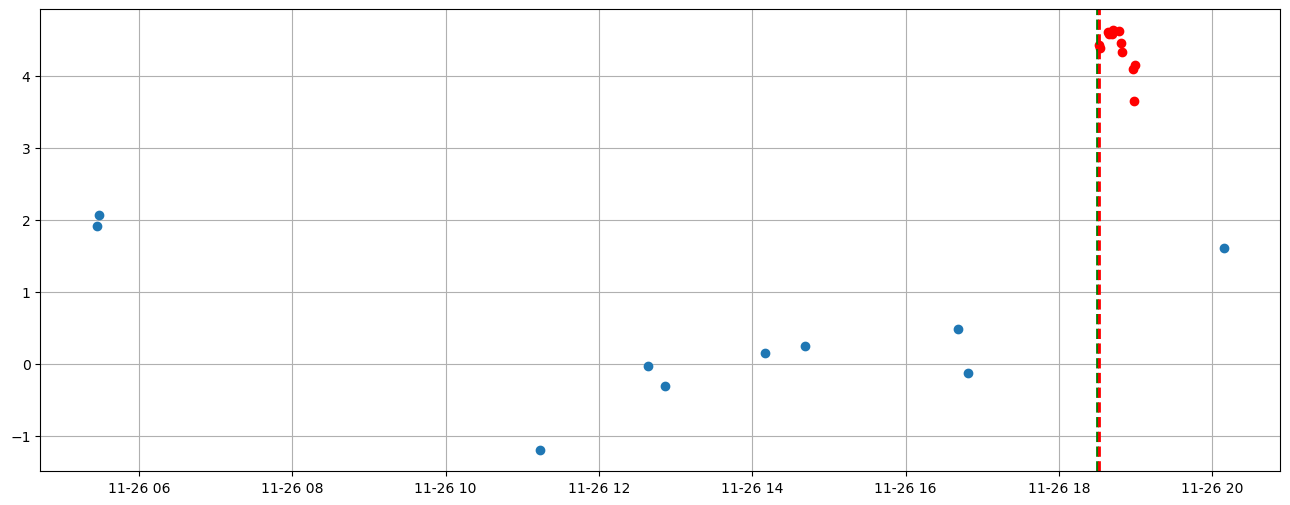

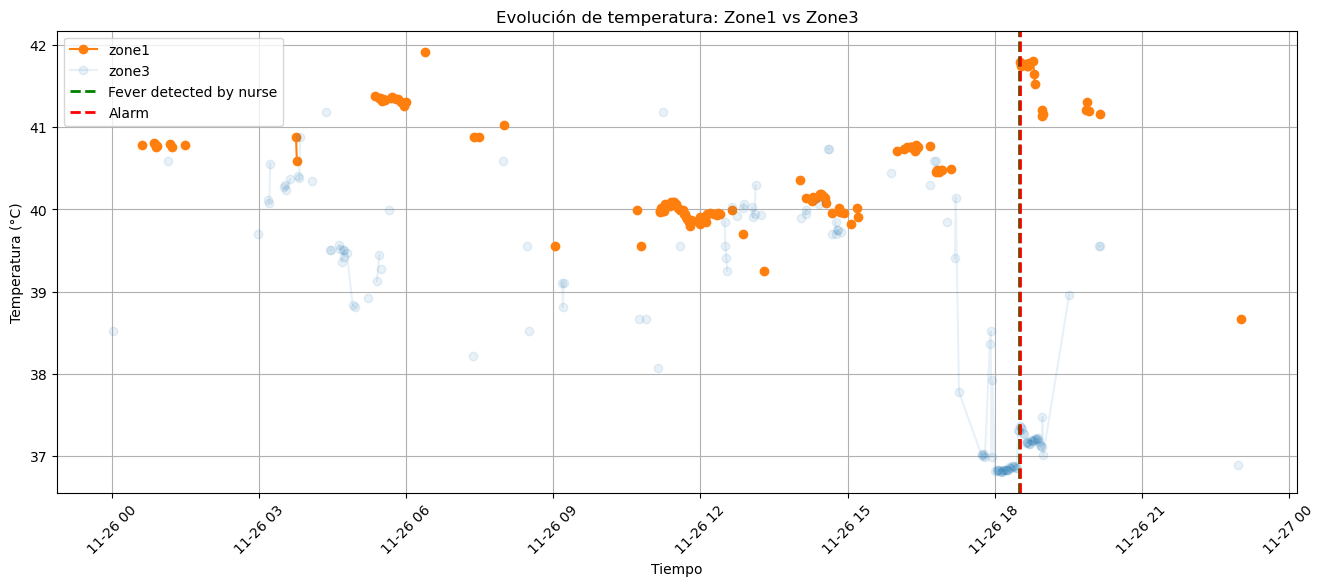

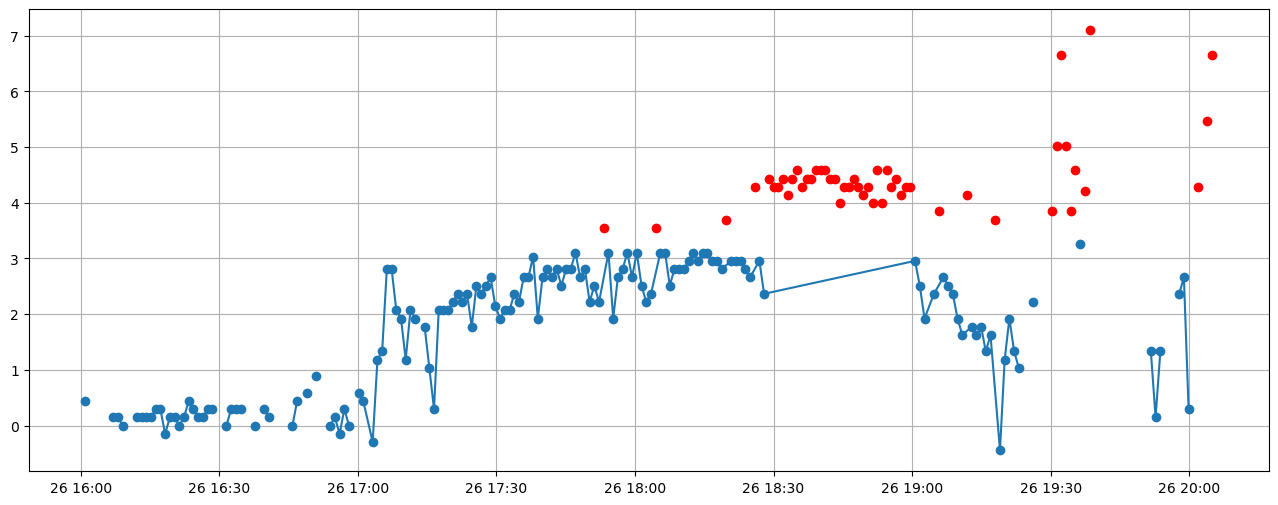

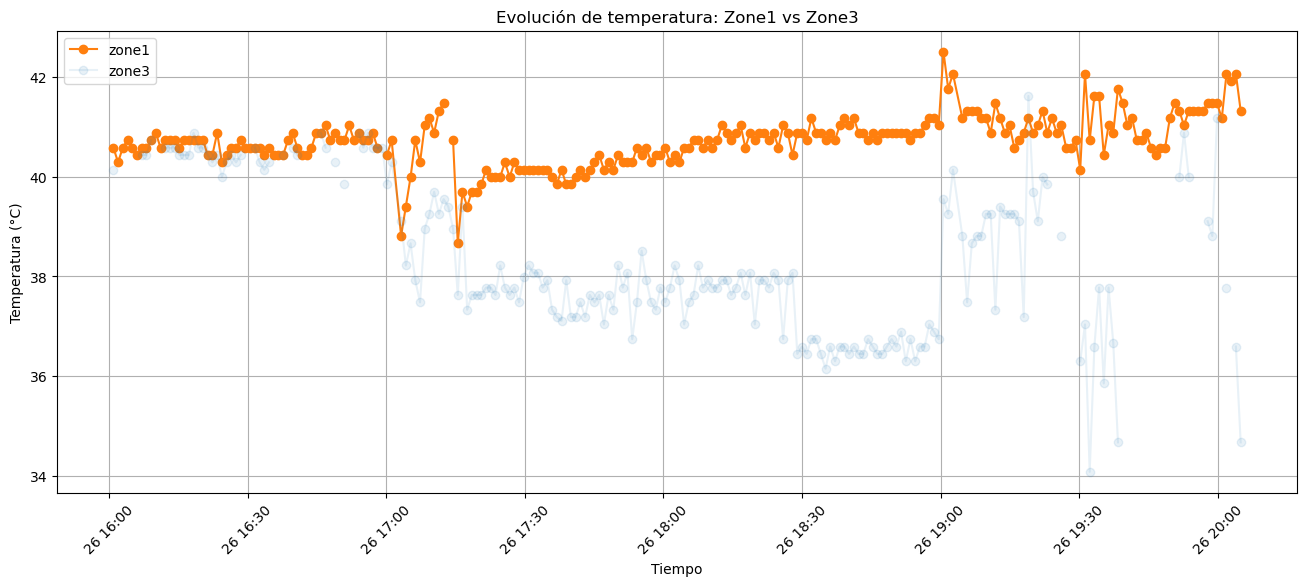

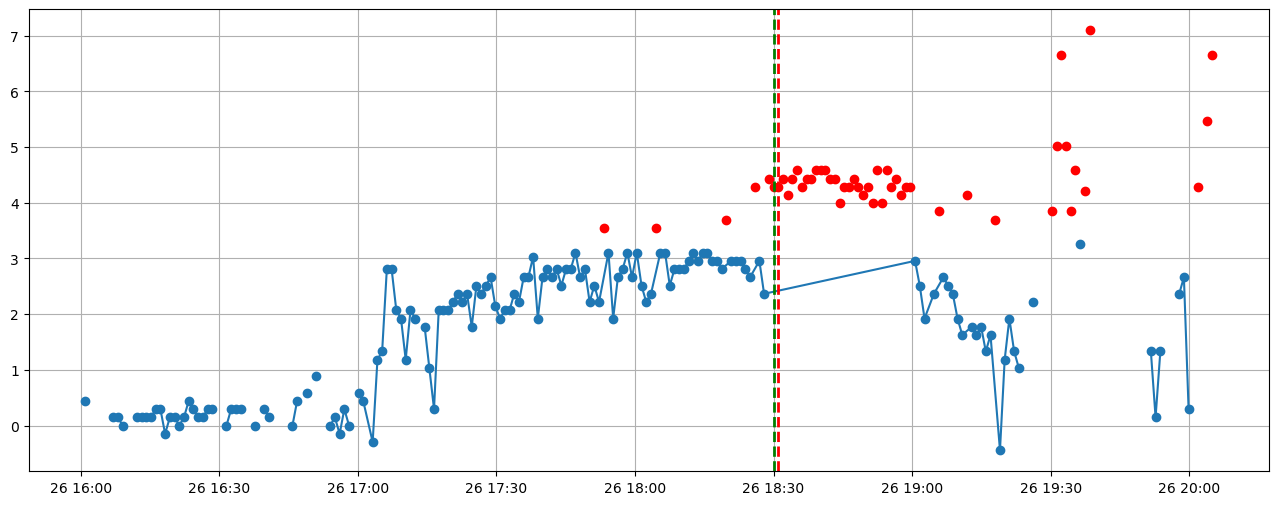

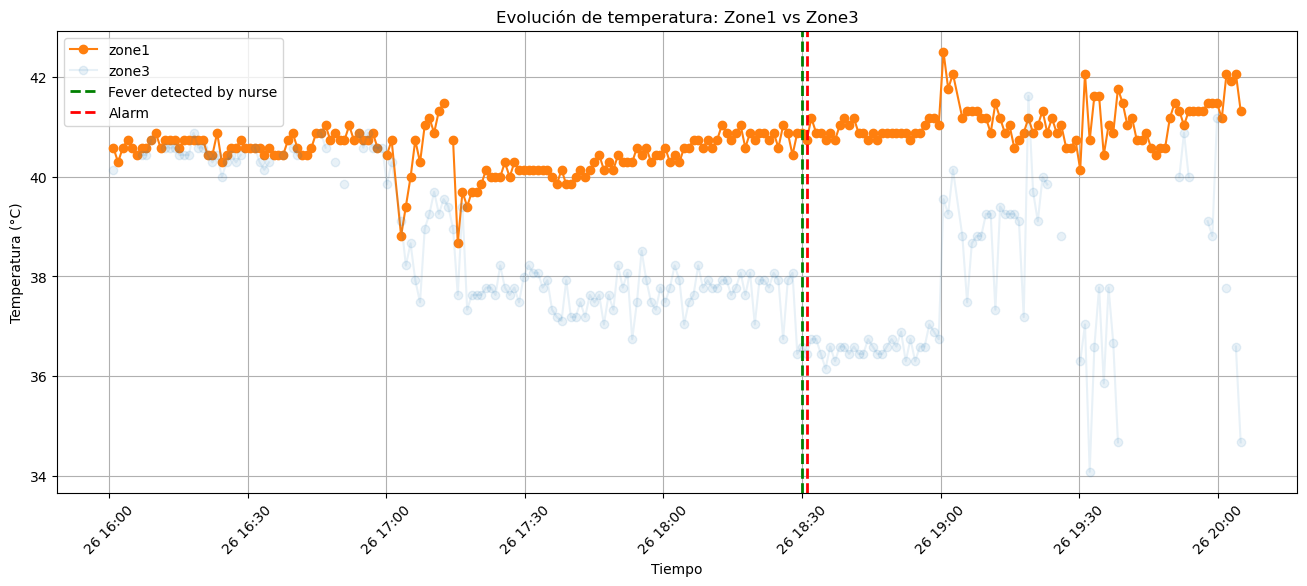

In [9]:
df_posture=adapt_df("csv_by_baby_smooth/baby_48.csv")
plots(df_posture)

df_human=adapt_df("timeserie_baby_48.csv")
plots(df_human)